In [27]:
import math
import matplotlib.pyplot as plt

In [28]:
def f(x):
    return 1.2 - ((x**2) / ((1 - x)**2)) * math.exp(-8.0 * x) + math.log(1 + x)

def df(x):
    term1 = (2 * x * (1 - x)**2 + 2 * x**2 * (1 - x)) / ((1 - x)**4)
    term2 = (8 * x**2) / ((1 - x)**2)
    return -(term1 * math.exp(-8.0 * x) - term2 * math.exp(-8.0 * x)) + (1 / (1 + x))

In [29]:
def newton_raphson(x0, tol):
    print(f"""{'Iter':<5}{'xk':<15}{'f(xk)':<15}{"f'(xk)":<15}{'x(new)':<15}{'ea (%)':<15}""")
    print("-" * 80)

    it = 0
    xr_old = x0
    errors = []

    while True:
        it += 1
        fx = f(xr_old)
        dfx = df(xr_old)

        if dfx == 0:
            print("Derivative zero. Not applicable")
            return None

        xr = xr_old - fx / dfx

        ea = abs((xr - xr_old) / xr) * 100
        errors.append(ea)

        print(f"{it:<5}{xr_old:<15.6f}{fx:<15.6f}{dfx:<15.6f}{xr:<15.6f}{ea:.6f}")

        if ea < tol:
            break

        xr_old = xr

    plt.figure()
    plt.plot(range(1, len(errors) + 1), errors, marker='o', color='r')
    plt.xlabel('Iteration')
    plt.ylabel('Approximate Error (%)')
    plt.title('Convergence of Approximate Error in Newton-Raphson Method')
    plt.grid(True)
    plt.show()

    return xr

Iter xk             f(xk)          f'(xk)         x(new)         ea (%)         
--------------------------------------------------------------------------------
1    -0.500000      -5.559608      66.708919      -0.416659      20.002296
2    -0.416659      -1.763644      29.327075      -0.356522      16.867714
3    -0.356522      -0.437611      16.077024      -0.329302      8.265869
4    -0.329302      -0.054609      12.239562      -0.324840      1.373488
5    -0.324840      -0.001201      11.705111      -0.324738      0.031603
6    -0.324738      -0.000001      11.693100      -0.324738      0.000016
7    -0.324738      -0.000000      11.693094      -0.324738      0.000000


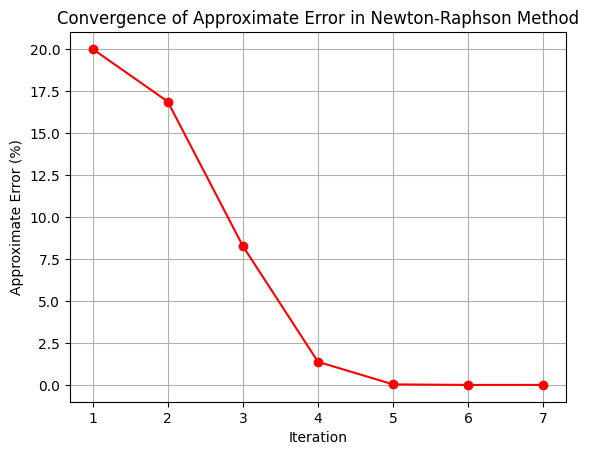


Approximate root: -0.324738



In [30]:
def main():
    tol = 0.00001
    x0 = -0.5
    root = newton_raphson(x0, tol)
    if root is not None:
        print(f"\nApproximate root: {root:.6f}\n")

if __name__ == "__main__":
    main()